# Bat Echolocation Call Exploration
Goal: Explore bat echolocation calls using waveforms, spectrograms, filters, etc. and extract features from individual calls, remove outliers, then average across all calls in a bat pass

--> Example bat pass used: 5/28/2025 recording from Albany, OR with higher pitched bat ~50 kHz not using strobe groups but with a loud feeding buzz

Steps:
1. Input a file
2. Apply filter to remove lower-frequency background noise below the bat calls
3. Normalize amplitude
4. Visualize
5. Use voice activity detection (VAD) with energy cutoff to get the timestamps for the bat calls and inter-call intervals (ICIs)
6. For each call within the bat pass (excluding first and last which could be cut off), extract the following features:
    - start time
    - end time
    - call duration
    - time until the next call
    - min frequency
    - max frequency
    - frequency of most energy
    - slope estimate assuming downward shape
7. Show those results in a table, with each column being a feature, and each row being a call
8. Check for outliers on each feature and remove calls with outliers
9. Check for presence of feeding buzzes, and extract the duration and min_freq in the feeding buzz
10. Get averages for the features and prep for export

Author: K Rubio

Last modified: 4/30/2026

In [1]:
import librosa
import librosa.display
from vad import EnergyVAD # https://pypi.org/project/energy-vad/
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import zscore
import os
import sys
from pathlib import Path

In [ ]:
# have to modify where notebook looks for imports so it looks in the project root, not the notebook folder
os.getcwd()
sys.path.append(str(Path().resolve().parent.parent))
print(sys.path)

['/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python312.zip', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12/lib-dynload', '', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/Data_Science/Audio Signal Processing/Potential Projects/2026_Audio_Signal_Analysis/audio-signal-analysis/.venv/lib/python3.12/site-packages', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/Data_Science/Audio Signal Processing/Potential Projects/2026_Audio_Signal_Analysis/audio-signal-analysis']


In [3]:
from utils.time_domain_utils import (
  plot_waveform,
  rms_normalize,
  get_voice_activity_timestamps,
  get_timestamps_silences,
  split_audio_by_timestamps
)
from utils.frequency_domain_utils import (
  plot_spectrogram,
  plot_spectrogram_zoom,
  ideal_frequency_filter,
  extract_min_max_and_most_energy_frequencies
)

## File input
Load a file with a bat pass using librosa and sampling rate of the ultrasound recorder. Check waveform

In [4]:
# Recordings done with dodotronic with sampling rate of 384,000
sr = 384000
filepath = '../data/audio/bat_20250528_2123_bp2.wav'

# Load audio with Librosa.load and sample at the correct rate
file, _ = librosa.load(filepath, sr=sr)


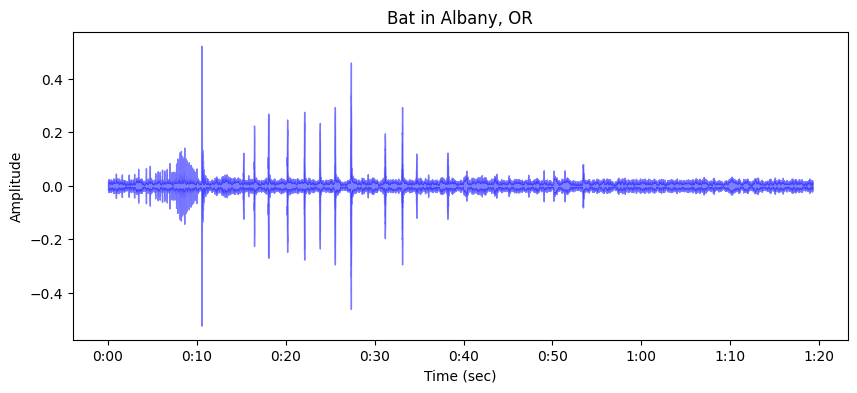

In [5]:
fig, ax = plot_waveform(file, "Bat in Albany, OR")

## Frequency Domain and Spectrogram
Apply the Short-Time Fourier Transform to convert to the frequency domain using frame length of 2048 and hop length of 1/4 of the frame length. Generate spectrogram to check work.

In [6]:
# Based on previous work, found that 2048 samples per frame works best for ultrasound in the time/frequency tradeoff 
# where larger frame sizes give better frequency resolution but worse time resolution
# for better onset detection, could lower this number to prioritize time resolution
# Use power of 2 which works best with Discrete Fourier transform (e.g., 512, 1024, 2048, 4096, 8192)
FRAME_LENGTH_SPEC = 2048

In [7]:
HOP_LENGTH_SPEC = FRAME_LENGTH_SPEC//4

In [8]:
# Apply the Short-Time Fourier Transform to convert to the frequency domain
stft_bat = librosa.stft(file, n_fft=FRAME_LENGTH_SPEC, hop_length=HOP_LENGTH_SPEC)
# STFT output is a matrix of complex numbers representing frequency content over time
stft_bat.shape

(1025, 2478)

In [9]:
stft_bat[0]

array([ 6.338703+0.j, 12.599729+0.j, 14.340989+0.j, ..., 11.884275+0.j,
        8.785712+0.j,  4.415515+0.j], shape=(2478,), dtype=complex64)

In [10]:
# Take the magnitude of each complex number to get an amplitude spectrum
# then square each magnitude to convert to power spectrogram
stft_bat_abs = np.abs(stft_bat) ** 2
# Convert spectrogram to a decibel (dB) scale which is logarithmic to make it easier to visualize
stft_bat_dB = librosa.power_to_db(np.abs(stft_bat_abs), ref=np.max)

(<Figure size 2500x400 with 1 Axes>,
 <Axes: title={'center': 'Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

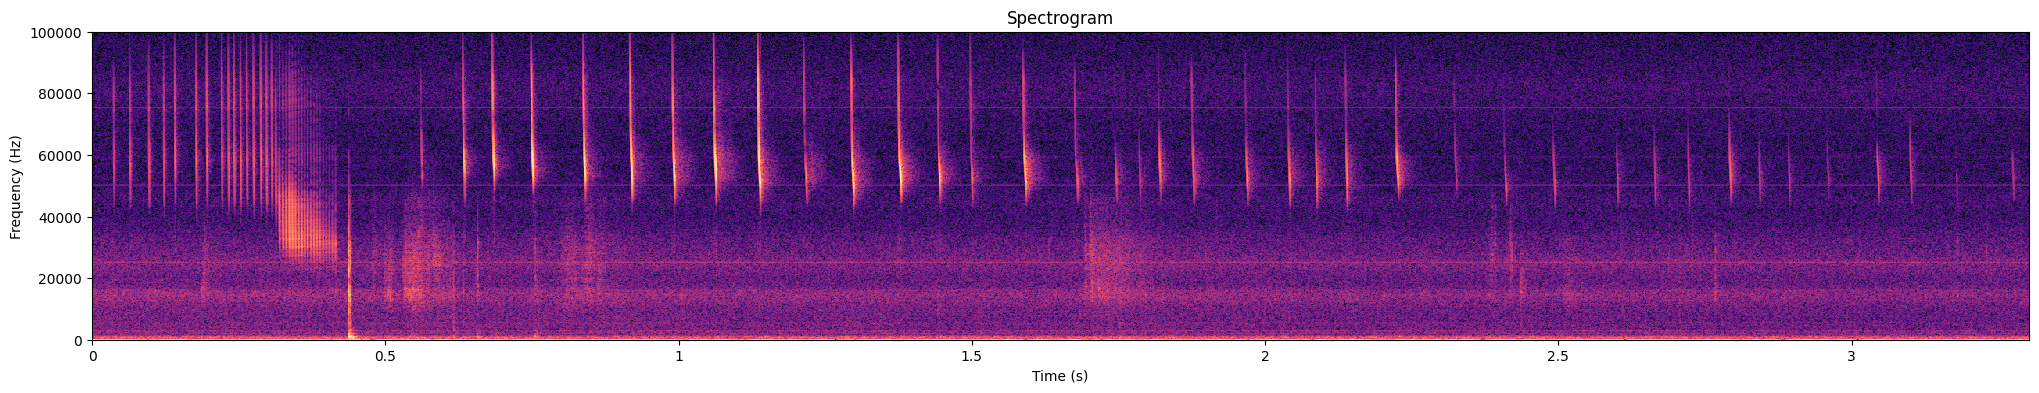

In [11]:
# Plot spectrogram
plot_spectrogram(stft_bat_dB, sr, HOP_LENGTH_SPEC, "linear", 0, 100000)

(<Figure size 2500x1000 with 1 Axes>,
 <Axes: title={'center': 'Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

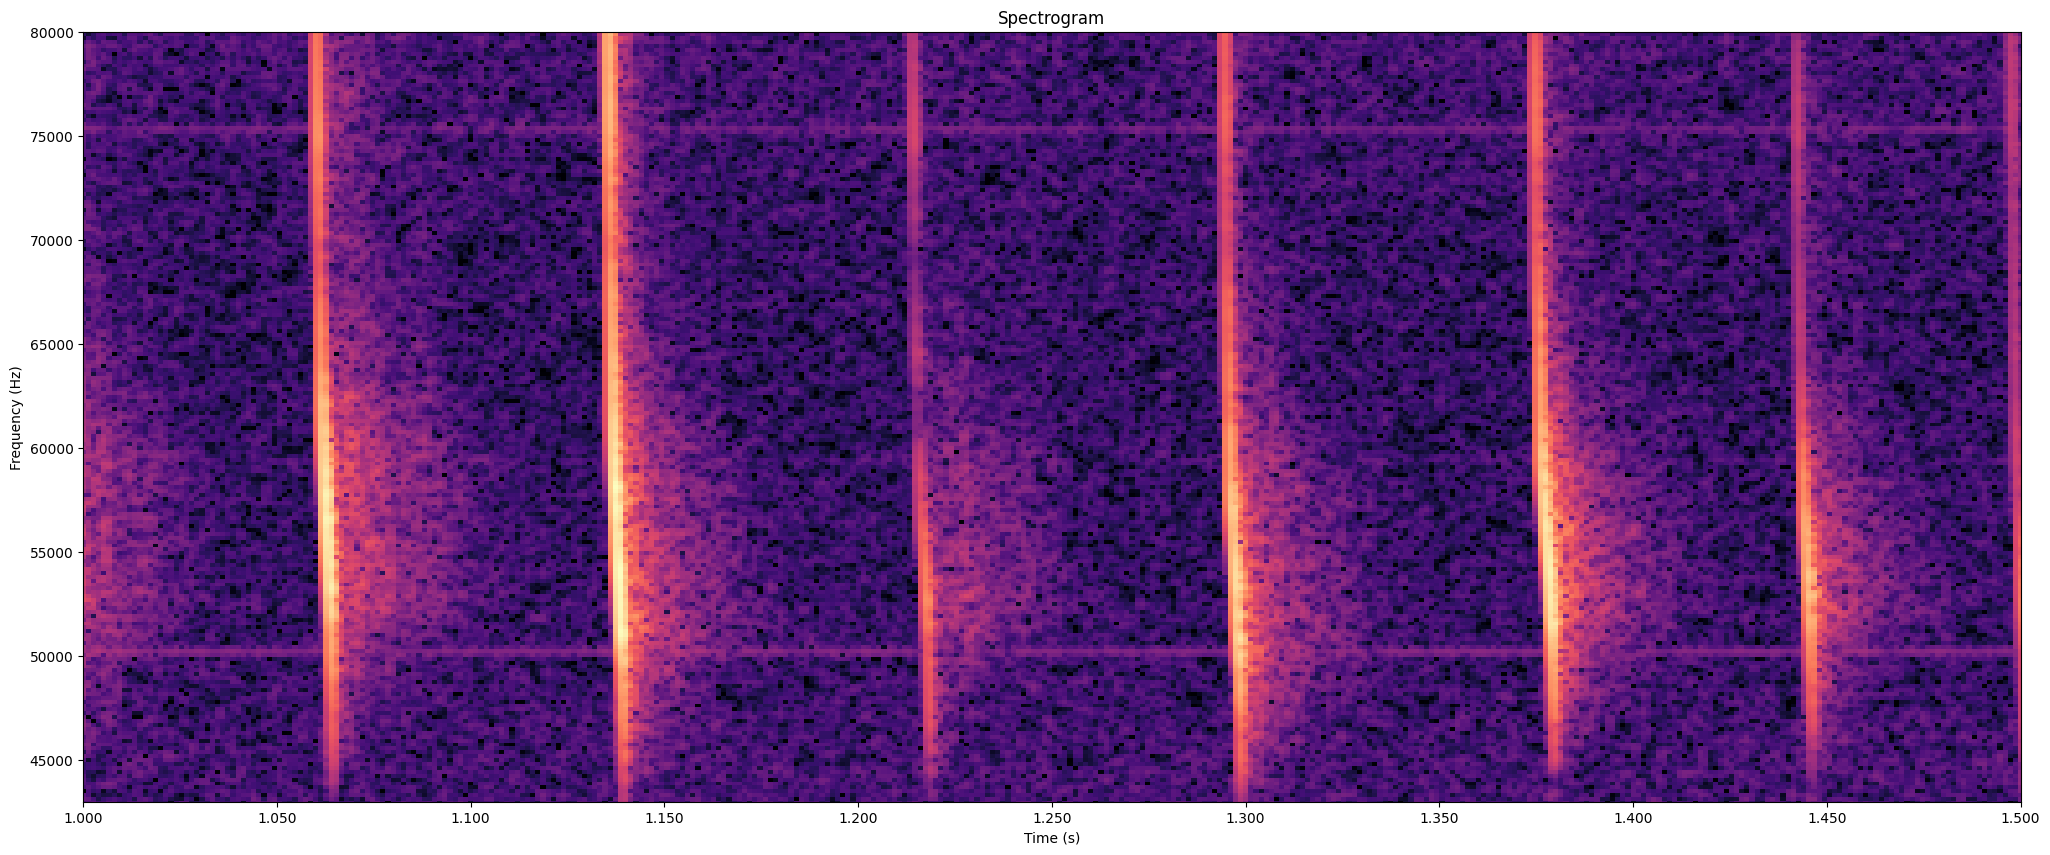

In [12]:
# Zoom in on highest frequencies and zoom in on time a bit to see more detail
plot_spectrogram_zoom(stft_bat_dB, sr, HOP_LENGTH_SPEC, "linear", 43000, 80000, 1, 1.5)

## Filter out lower frequency background noise
Filter out lower frequency background noise by zeroing out all values below a cutoff (e.g., 15 or 20 kHz). Generate spectrogram to check work. Convert back to the time domain using the inverse STFT

In [13]:
# This particular bat is echolocating above 32 kHz, and would like to cut out background as well as lower
# pitched bat below
# Apply a cutoff, and zero out all the values below and isolate the bat sounds
CUTOFF = 20000

In [14]:
# high ideal frequency filter zero's out all frequencies below a cutoff
result = ideal_frequency_filter(stft_bat, sr, FRAME_LENGTH_SPEC, CUTOFF, 'high')

In [15]:
frequencies = result['frequencies']
stft_filtered = result['stft_filtered']
stft_bat_filtered_abs = result['stft_filtered_abs']
stft_filtered_dB = result['stft_filtered_dB']
stft_filtered

array([[ 0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        , ...,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ],
       [ 0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        , ...,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ],
       [ 0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        , ...,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ],
       ...,
       [ 0.01160323+0.01434207j, -0.00047773-0.00871292j,
        -0.00165207-0.00553948j, ...,  0.0026294 -0.0296819j ,
        -0.01722828+0.01532857j,  0.02450473-0.00240758j],
       [-0.0227998 -0.0129651j , -0.01801652+0.01742611j,
         0.00704077+0.01908464j, ..., -0.0096899 +0.02725659j,
         0.01344448-0.01522397j, -0.02471973-0.00310672j],
       [ 0.03001441+0.j        ,  0.0252047 +0.j        ,
        -0.01179583+0.j       

(<Figure size 2500x400 with 1 Axes>,
 <Axes: title={'center': 'Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

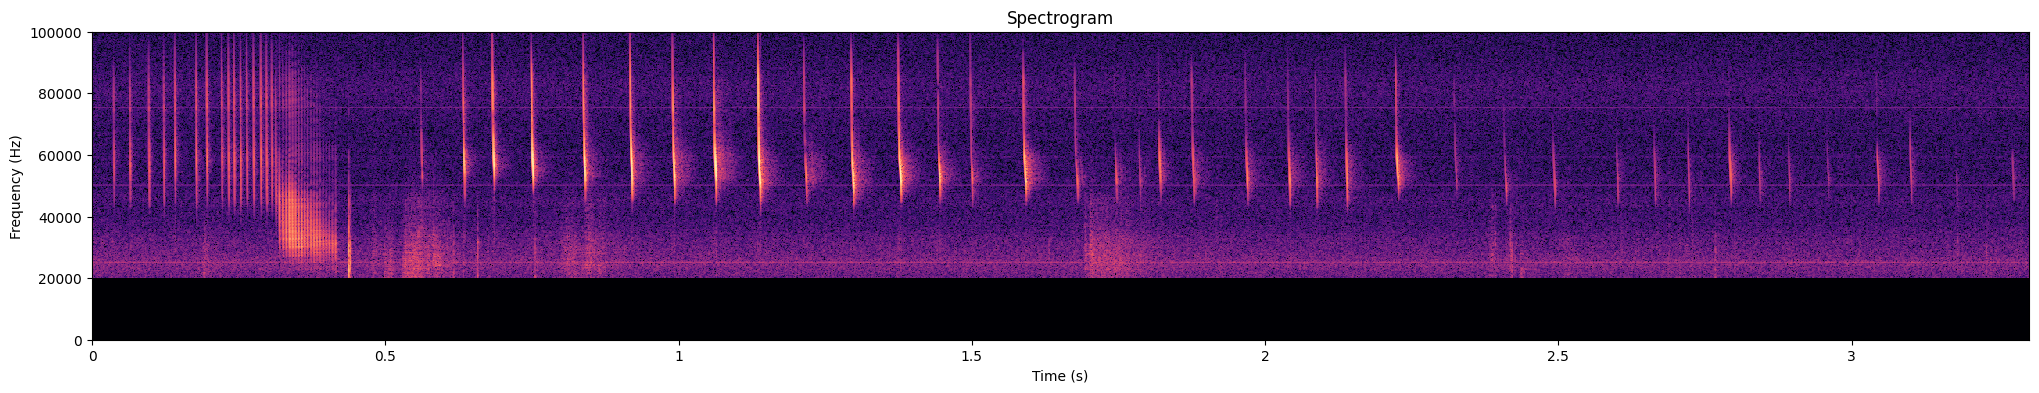

In [16]:
# Plot spectrogram for bats with lower frequency sounds filtered out
plot_spectrogram(stft_filtered_dB, sr, HOP_LENGTH_SPEC, "linear", 0, 100000)

In [17]:
# Convert back to the time domain using the inverse STFT
bat_filtered = librosa.istft(stft_filtered, hop_length=HOP_LENGTH_SPEC)

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Bat sounds only'}, xlabel='Time (sec)', ylabel='Amplitude'>)

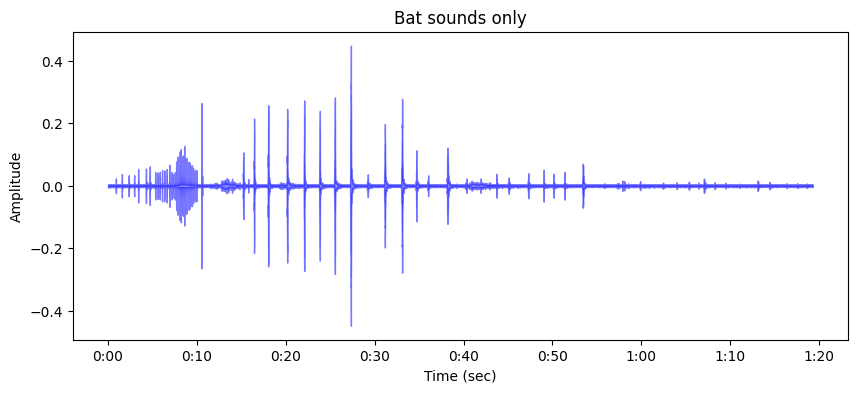

In [18]:
plot_waveform(bat_filtered, "Bat sounds only")

## Normalize amplitude (volume)
Normalize audio signal so amplitude/volume is consistent across files using root mean square energy. Generate waveform and spectrogram to check work. Then re-apply the Short-Time Fourier Transform to convert to the frequency domain.

In [19]:
# this will make the mean close to zero and the variance close to .001
bat_filtered_normalized = rms_normalize(bat_filtered, target_dBFS=-30.0)

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Bat sounds with normalized amplitude'}, xlabel='Time (sec)', ylabel='Amplitude'>)

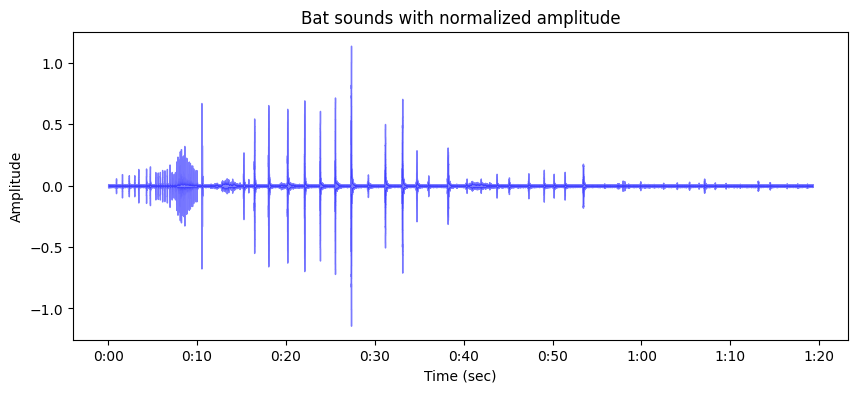

In [20]:
plot_waveform(bat_filtered_normalized, "Bat sounds with normalized amplitude")

In [21]:
# Re-apply the Short-Time Fourier Transform to convert to the frequency domain using normalized file
stft_bat_filtered = librosa.stft(bat_filtered_normalized, n_fft=FRAME_LENGTH_SPEC, hop_length=HOP_LENGTH_SPEC)
stft_bat_filtered.shape

(1025, 2478)

In [22]:
stft_bat_filtered_abs = np.abs(stft_bat_filtered) ** 2
stft_bat_filtered_dB = librosa.power_to_db(np.abs(stft_bat_filtered_abs), ref=np.max)

(<Figure size 2500x400 with 1 Axes>,
 <Axes: title={'center': 'Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

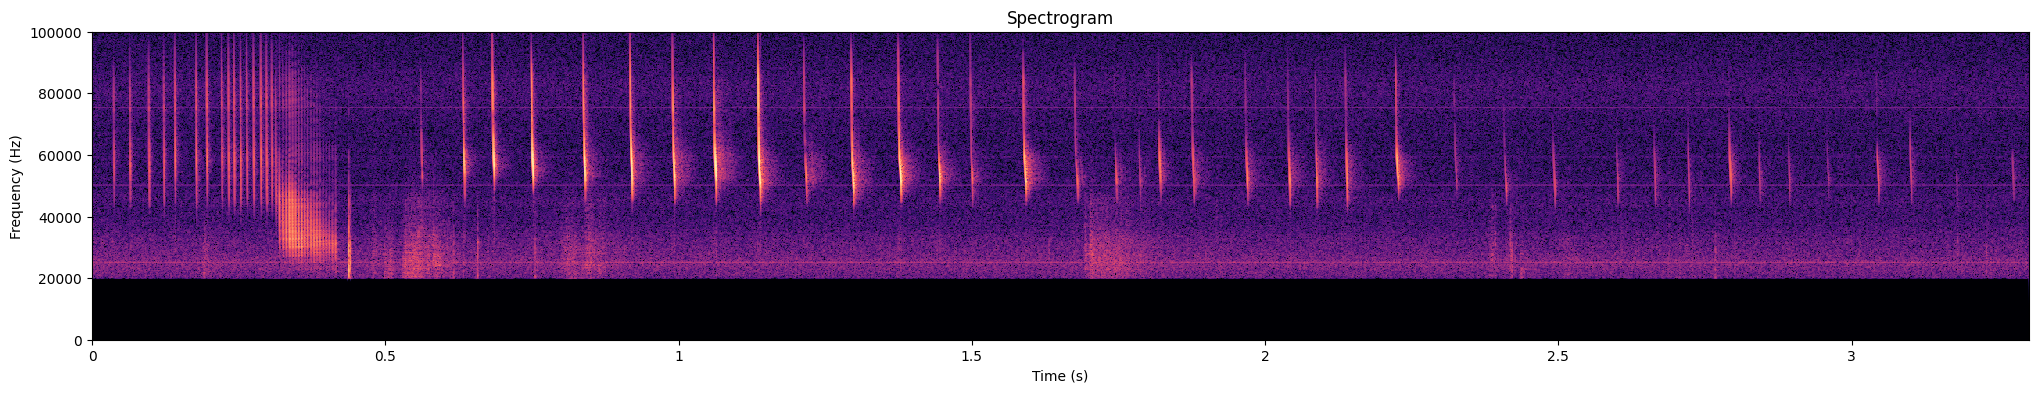

In [23]:
# Plot spectrogram
plot_spectrogram(stft_bat_filtered_dB, sr, HOP_LENGTH_SPEC, "linear", 0, 100000)

## Using VAD to extract timestamps for individual calls
Apply energy voice activity detection (VAD) using very short frame length of 5ms and frame shift of 2ms, and an energy threshold (e.g., 0.04) to detect which frames have sounds (coded as 1) and which frames have silence (coded as 0).
Then use the VAD output to get timestamps for each echolocation call within the file and the inter-call intervals (ICIs). Use visualizations to check this output on the original waveform. 

In [24]:
# For non-bat sounds, 25 would be used, but that's too long for many bats
# for some bats 10 works, but some need shorter lengths
FRAME_LENGTH = 5 # milliseconds
FRAME_SHIFT = 2 # milliseconds
# Generally a silence longer than 90ms is should separate one search call from another
MIN_ICI = 20 # in milliseconds
# call might be 19ms (3-50ms) or 0.5ms for micro-calls, while a ICI might be like 228ms
# Search phase ICI's are ~100 ms or longer
# Approach phase ICI's are ~20 ms
# Feeding buzz ICI's are ~9-18 ms

ENERGY_THRESHOLD = 0.04


In [25]:
# Initialize VAD and get the output, which is an array of 0's and 1's, where 0 = frame with silence
# and 1 = frame with voice activity above the energy threshold
vad = EnergyVAD(frame_length=FRAME_LENGTH, frame_shift=FRAME_SHIFT, sample_rate=sr, energy_threshold=ENERGY_THRESHOLD)
vad_output = vad(bat_filtered_normalized)

In [26]:
# Get timestamps for calls
calls = get_voice_activity_timestamps(vad_output=vad_output, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_ICI)
calls[1:3]


[{'start': 0.06, 'end': 0.066}, {'start': 0.092, 'end': 0.098}]

In [27]:
len(calls)

41

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Bat in Melrose MA'}, xlabel='Time (sec)', ylabel='Amplitude'>)

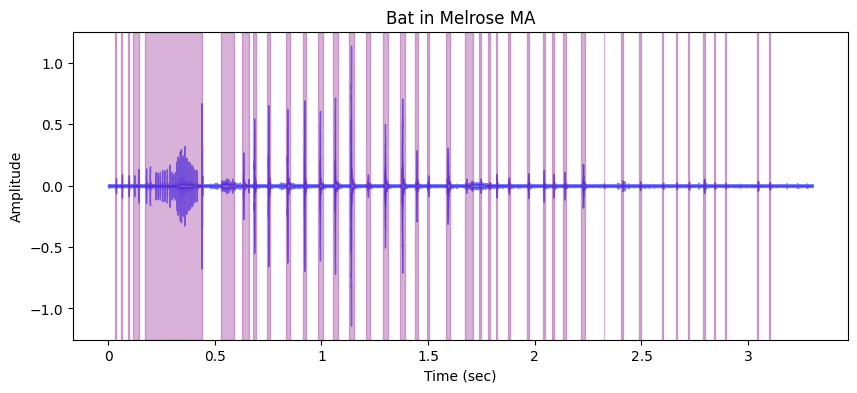

In [28]:
plot_waveform(bat_filtered_normalized, 'Bat in Melrose MA', sr, calls)

In [29]:
# Get timestamps for silences between calls
icis = get_timestamps_silences(vad_output=vad_output, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_ICI)
icis[0:3]

[{'start': 0.0, 'end': 0.03},
 {'start': 0.04, 'end': 0.06},
 {'start': 0.07, 'end': 0.09}]

In [30]:
len(icis)

42

In [31]:
# If the first ICI starts at 0, cut it off since we don't want that at the beginning
if icis[0]['start'] == 0:
    icis = icis[1:]
icis[0:3]

[{'start': 0.04, 'end': 0.06},
 {'start': 0.07, 'end': 0.09},
 {'start': 0.1, 'end': 0.12}]

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Bat in Melrose MA'}, xlabel='Time (sec)', ylabel='Amplitude'>)

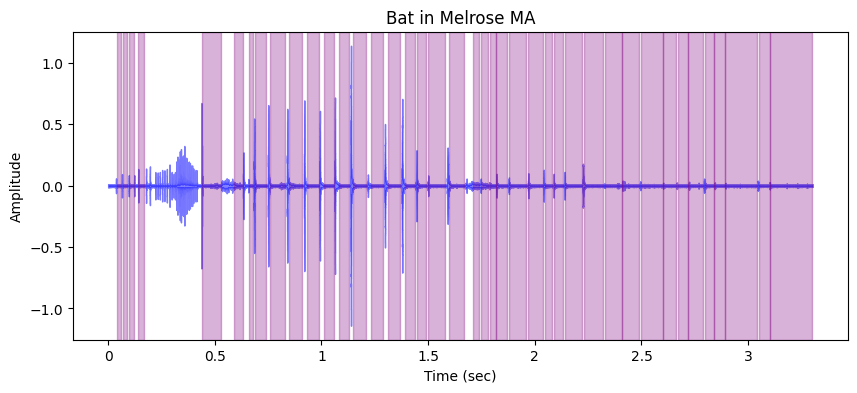

In [32]:
plot_waveform(bat_filtered_normalized, 'Bat in Melrose MA', sr, icis)

In [33]:
# Zoom in on a specific section which looks pretty loud
audio_sections = split_audio_by_timestamps(bat_filtered_normalized, [{'start': 0.75, 'end': 1}], sr)
section = audio_sections[0]
section

array([ 0.18412751,  0.19706781, -0.00256204, ..., -0.02627747,
       -0.01368586,  0.00539332], shape=(96000,), dtype=float32)

In [34]:
vad_output_section = vad(section)

In [35]:
# Get timestamps for calls
section_calls = get_voice_activity_timestamps(
    vad_output=vad_output_section,
    frame_shift=FRAME_SHIFT,
    min_silence_duration=MIN_ICI)
section_calls

[{'start': 0.0, 'end': 0.008},
 {'start': 0.084, 'end': 0.104},
 {'start': 0.164, 'end': 0.178},
 {'start': 0.236, 'end': 0.248}]

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Bat in Melrose MA'}, xlabel='Time (sec)', ylabel='Amplitude'>)

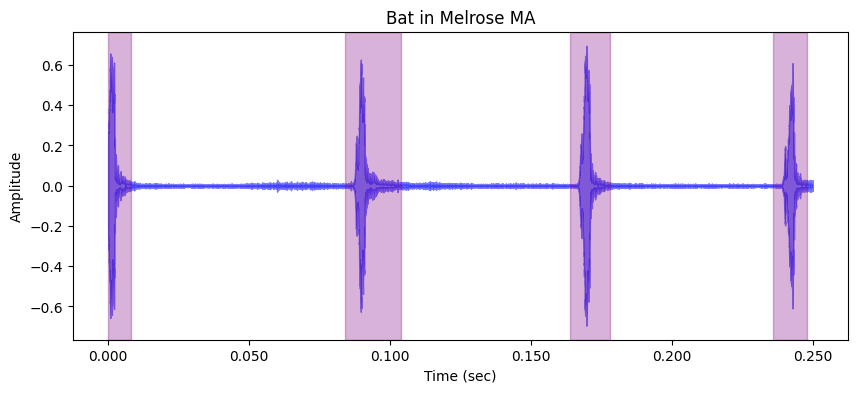

In [36]:
plot_waveform(section, 'Bat in Melrose MA', sr, section_calls)

Attack-decay-sustain-release (ADSR) model of the sound envelope of these bat calls includes a sharp attack, a very steep decay, then a longer sustain/release.

In [37]:
# Get timestamps for silences between calls
icis_section = get_timestamps_silences(vad_output=vad_output_section, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_ICI)
icis_section

[{'start': 0.01, 'end': 0.08},
 {'start': 0.1, 'end': 0.16},
 {'start': 0.18, 'end': 0.24}]

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Bat in Melrose MA'}, xlabel='Time (sec)', ylabel='Amplitude'>)

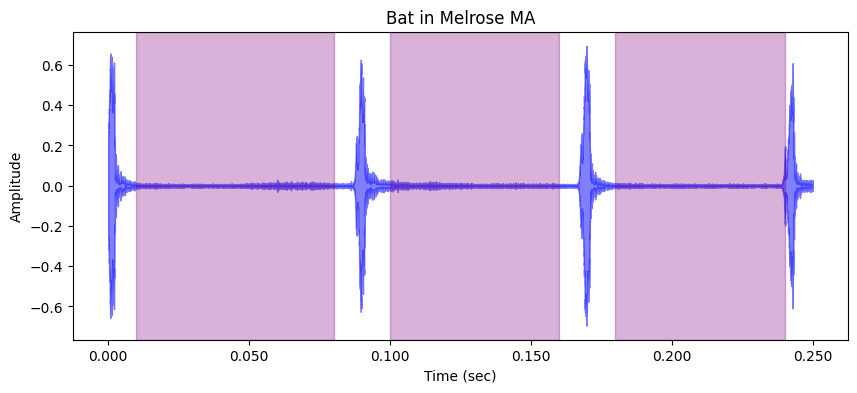

In [38]:
plot_waveform(section, 'Bat in Melrose MA', sr, icis_section)

## Extract time domain data and store in dataframe
Use timestamps to extract duration and ici for each call, and create a pandas data frame where one row is a call and columns include start, end, duration, and time to next call.

In [39]:
# Create pandas data frame with the start/end for each call
# iterate over calls and put all the start times in one list, and all the end times in another list
starts = []
ends = []
durations_ms = []
for call in calls:
    starts.append(call['start'])
    ends.append(call['end'])
    durations_ms.append((call['end'] - call['start']) * 1000)
start_end_data = {'start': starts, 'end': ends, 'duration_ms': durations_ms}
df = pd.DataFrame(start_end_data)
df

,start,end,duration_ms
0,0.032,0.038,6.0
1,0.060,0.066,6.0
2,0.092,0.098,6.0
3,0.118,0.144,26.0
4,0.174,0.442,268.0
5,0.530,0.592,62.0
6,0.628,0.658,30.0
7,0.678,0.692,14.0
8,0.744,0.758,14.0
9,0.834,0.854,20.0


In [40]:
# Add time_to_next_call_ms to the dataframe
time_to_next_call_ms = []
for ici in icis:
    time_to_next_call_ms.append((ici['end'] - ici['start']) * 1000)
df['time_to_next_call_ms'] = time_to_next_call_ms
df

,start,end,duration_ms,time_to_next_call_ms
0,0.032,0.038,6.0,20.0
1,0.060,0.066,6.0,20.0
2,0.092,0.098,6.0,20.0
3,0.118,0.144,26.0,30.0
4,0.174,0.442,268.0,90.0
5,0.530,0.592,62.0,40.0
6,0.628,0.658,30.0,20.0
7,0.678,0.692,14.0,50.0
8,0.744,0.758,14.0,70.0
9,0.834,0.854,20.0,60.0


In [41]:
print(df.shape)

(41, 4)


In [42]:
avg_call_duration = df['duration_ms'].mean()
avg_ici_duration = df['time_to_next_call_ms'].mean()
print(f"Average call duration is {avg_call_duration:.2f} ms")
print(f"Average intercall-interval is {avg_ici_duration:.2f} ms")

Average call duration is 20.05 ms
Average intercall-interval is 60.00 ms


## Extract frequency domain data
For each call, use the frequency data and an energy cutoff (e.g., 0.04) to extract the minimum frequency, maximum frequency, and frequency with most energy. Add these as columns to the  data frame.

In [43]:
# Already computed: stft_bat_filtered_abs
# Already computed: bat_frequencies = librosa.fft_frequencies(sr=sr, n_fft=FRAME_LENGTH_SPEC)
times = librosa.frames_to_time(
  np.arange(stft_bat_filtered_abs.shape[1]),
  sr=sr,
  hop_length=HOP_LENGTH_SPEC
)

In [44]:
frequency_data = []
for call in calls:
    energy_cutoff = 0.04
    call_data = extract_min_max_and_most_energy_frequencies(
        stft_bat_filtered_abs,
        times,
        call['start'],
        call['end'],
        energy_cutoff,
        frequencies)
    frequency_data.append(call_data)

In [45]:
len(frequency_data)

41

In [46]:
# Check the first 2 rows
frequency_data[0:2]

[{'min_freq': np.float64(20250.0),
  'max_freq': np.float64(150750.0),
  'max_energy_freq': np.float64(56250.0)},
 {'min_freq': np.float64(25125.0),
  'max_freq': np.float64(150750.0),
  'max_energy_freq': np.float64(56437.5)}]

In [47]:
# Add these as columns to the data frame
min_freqs = []
max_freqs = []
max_energy_freqs = []
for row in frequency_data:
    min_freqs.append(row['min_freq'])
    max_freqs.append(row['max_freq'])
    max_energy_freqs.append(row['max_energy_freq'])
df['min_freq'] = min_freqs
df['max_freq'] = max_freqs  
df['max_energy_freq'] = max_energy_freqs
df.head()

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq
0,0.032,0.038,6.0,20.0,20250.0,150750.0,56250.0
1,0.060,0.066,6.0,20.0,25125.0,150750.0,56437.5
2,0.092,0.098,6.0,20.0,22875.0,150750.0,57562.5
3,0.118,0.144,26.0,30.0,24937.5,150750.0,57937.5
4,0.174,0.442,268.0,90.0,20250.0,76500.0,32812.5


In [48]:
avg_min_freq = df['min_freq'].mean()
avg_max_freq = df['max_freq'].mean()
avg_freq_of_most_energy = df['max_energy_freq'].mean()
print(f"Average min frequency is {avg_min_freq:.2f} Hz")
print(f"Average max frequency is {avg_max_freq:.2f} Hz")
print(f"Average frequency of most energy is {avg_freq_of_most_energy:.2f} Hz")

Average min frequency is 33347.56 Hz
Average max frequency is 103239.33 Hz
Average frequency of most energy is 52042.68 Hz


### Simple slope
For each call, create a simple estimate of slope in Hz/ms (assuming downward trajectory) using:

m = (y2 – y1) / (x2 – x1)

 - x1 = start_time,
 - y1 = max_freq,
 - x2 = end_time,
 - y2 = min_freq

simple_slope = (min_freq – max_freq) / (end_time - start_time)

add this to the data frame

In [49]:
# Looking at one of the louder calls in the middle
call_index = 10
frequency_data[call_index]

{'min_freq': np.float64(49500.0),
 'max_freq': np.float64(66937.5),
 'max_energy_freq': np.float64(57937.5)}

In [50]:
calls[call_index]

{'start': 0.914, 'end': 0.928}

In [51]:
call1_min_freq = frequency_data[call_index]['min_freq']
call1_max_freq = frequency_data[call_index]['max_freq']
call1_start_time = calls[call_index]['start']
call1_end_time = calls[call_index]['end']

(<Figure size 2500x1000 with 1 Axes>,
 <Axes: title={'center': 'Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

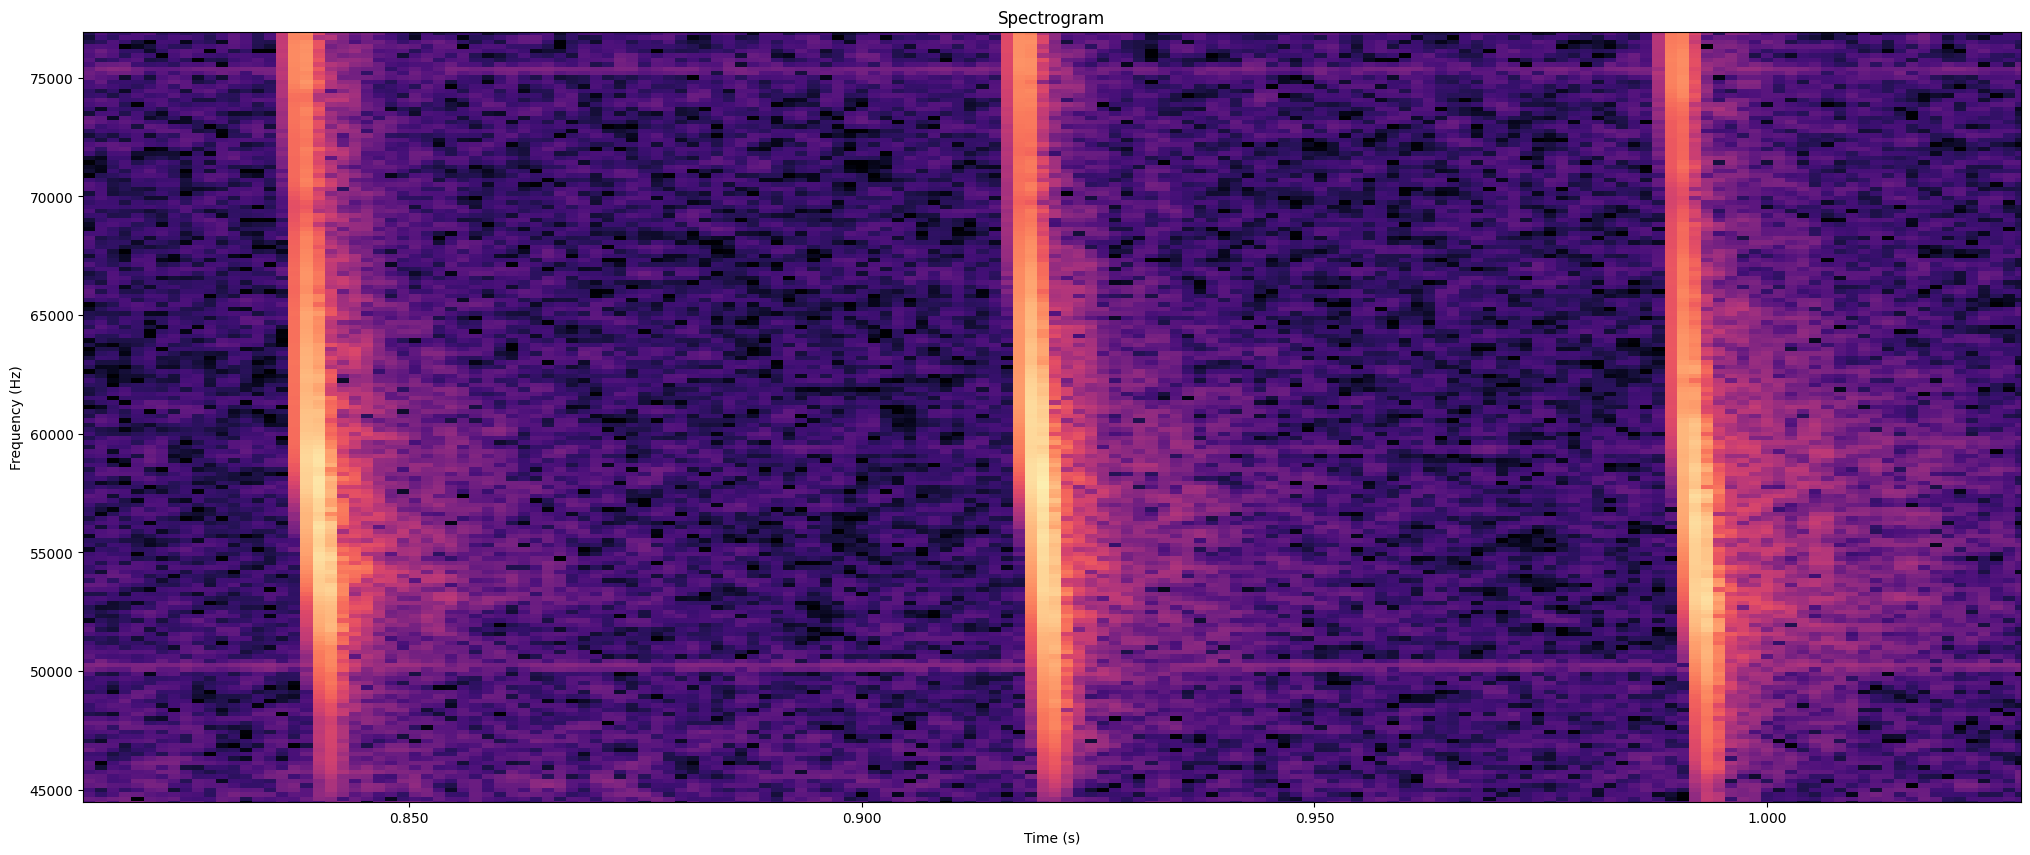

In [52]:
plot_spectrogram_zoom(
    stft_bat_filtered_dB,
    sr,
    HOP_LENGTH_SPEC,
    "linear",
    call1_min_freq - 5000,
    call1_max_freq + 10000,
    call1_start_time - 0.1,
    call1_end_time + 0.1)

In [53]:
# Calculate a simple slope for the call above
duration_change = call1_min_freq - call1_max_freq
time_change = (call1_end_time - call1_start_time) * 1000 # convert s to ms
simple_slope = duration_change / time_change
print(f'slope of a call: {simple_slope:.2f} Hz/ms')

slope of a call: -1245.54 Hz/ms


In [54]:
# Calculate simple slopes for all calls and add to table
df['slope'] = (df['min_freq'] - df['max_freq']) / ((df['end'] - df['start']) * 1000)
df.head()

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
0,0.032,0.038,6.0,20.0,20250.0,150750.0,56250.0,-21750.000000
1,0.060,0.066,6.0,20.0,25125.0,150750.0,56437.5,-20937.500000
2,0.092,0.098,6.0,20.0,22875.0,150750.0,57562.5,-21312.500000
3,0.118,0.144,26.0,30.0,24937.5,150750.0,57937.5,-4838.942308
4,0.174,0.442,268.0,90.0,20250.0,76500.0,32812.5,-209.888060


## Data cleaning
Do some data cleaning on the resulting data frame. Remove first and last call (which may be partially cut off in some files), check and remove individual data points that are outliers (z-score above 3). This process helps filter out unusual data from feeding buzzes and extra noises that aren't bat-related.

In [55]:
df.shape

(41, 8)

In [56]:
# Drop first and last row, as first and last call may be cut off, and/or have innacurate time_to_next_call
df2 = df.iloc[1:-1]
df2.shape

(39, 8)

In [57]:
df2

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
1,0.060,0.066,6.0,20.0,25125.0,150750.0,56437.5,-20937.500000
2,0.092,0.098,6.0,20.0,22875.0,150750.0,57562.5,-21312.500000
3,0.118,0.144,26.0,30.0,24937.5,150750.0,57937.5,-4838.942308
4,0.174,0.442,268.0,90.0,20250.0,76500.0,32812.5,-209.888060
5,0.530,0.592,62.0,40.0,20062.5,150750.0,25500.0,-2107.862903
6,0.628,0.658,30.0,20.0,52875.0,77062.5,57937.5,-806.250000
7,0.678,0.692,14.0,50.0,53062.5,66187.5,56625.0,-937.500000
8,0.744,0.758,14.0,70.0,51187.5,66000.0,58875.0,-1058.035714
9,0.834,0.854,20.0,60.0,51187.5,77062.5,58125.0,-1293.750000
10,0.914,0.928,14.0,60.0,49500.0,66937.5,57937.5,-1245.535714


In [58]:
# Look at duration outliers, first create a copy of the original data frame (to preserve original indexing)
df_zscores = df2.copy()
df_zscores.drop(['duration_ms', 'time_to_next_call_ms', 'min_freq', 'max_freq', 'max_energy_freq', 'slope'], axis=1, inplace=True)
df_zscores['duration_ms'] = zscore(df2['duration_ms'])
df_zscores['time_to_next_call_ms'] = zscore(df2['time_to_next_call_ms'])
df_zscores['min_freq'] = zscore(df2['min_freq'])
df_zscores['max_freq'] = zscore(df2['max_freq'])
df_zscores['max_energy_freq'] = zscore(df2['max_energy_freq'])
df_zscores['slope'] = zscore(df2['slope'])
df_zscores

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
1,0.060,0.066,-0.355406,-1.468542,-0.666709,1.179407,0.603580,-1.023517
2,0.092,0.098,-0.355406,-1.468542,-0.835642,1.179407,0.753514,-1.056454
3,0.118,0.144,0.125873,-1.076261,-0.680787,1.179407,0.803492,0.390454
4,0.174,0.442,5.949350,1.277431,-1.032731,-0.573867,-2.545031,0.797034
5,0.530,0.592,0.992175,-0.683979,-1.046809,1.179407,-3.519601,0.630331
6,0.628,0.658,0.222129,-1.468542,1.416802,-0.560585,0.803492,0.744654
7,0.678,0.692,-0.162894,-0.291697,1.430880,-0.817377,0.628569,0.733126
8,0.744,0.758,-0.162894,0.492867,1.290102,-0.821805,0.928437,0.722539
9,0.834,0.854,-0.018511,0.100585,1.290102,-0.560585,0.828481,0.701836
10,0.914,0.928,-0.162894,0.100585,1.163402,-0.799668,0.803492,0.706071


In [59]:
duration_outliers = df_zscores[abs(df_zscores['duration_ms']) > 3]
duration_outliers.index.tolist()

[4]

In [60]:
time_to_next_call_ms_outliers = df_zscores[abs(df_zscores['time_to_next_call_ms']) > 3]
time_to_next_call_ms_outliers.index.tolist()

[38]

In [61]:
min_freq_outliers = df_zscores[abs(df_zscores['min_freq']) > 3]
min_freq_outliers.index.tolist()

[]

In [62]:
max_freq_outliers = df_zscores[abs(df_zscores['max_freq']) > 3]
max_freq_outliers.index.tolist()

[]

In [63]:
max_energy_freq_outliers = df_zscores[abs(df_zscores['max_energy_freq']) > 3]
max_energy_freq_outliers.index.tolist()

[5, 22]

In [64]:
slope_outliers = df_zscores[abs(df_zscores['slope']) > 3]
slope_outliers.index.tolist()

[]

In [65]:
# Call 4 has an unusually long duration, but that's because it's a feeding buzz, so lets set that one aside
# and remove it from this table
feeding_buzz = df2.loc[4]
df3 = df2.drop([4])

In [66]:
# Call 38 has an unusually long time to next call, but based on the spectrogram, the calls were fading into the distance
# so just clear that outlier 
df3.loc[38, 'time_to_next_call_ms'] = np.nan

In [67]:
# Calls 5 and 22 have unusual max_energy_freq
# Call 5 was right before the feeding buzz when the bat was dropping it's frequency, so lets just clear that outlier
df3.loc[5, 'max_energy_freq'] = np.nan
# Visualize call 22 to see what's going on

In [68]:
print(df2.loc[22]['max_energy_freq'])

25125.0


(<Figure size 2500x1000 with 1 Axes>,
 <Axes: title={'center': 'Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

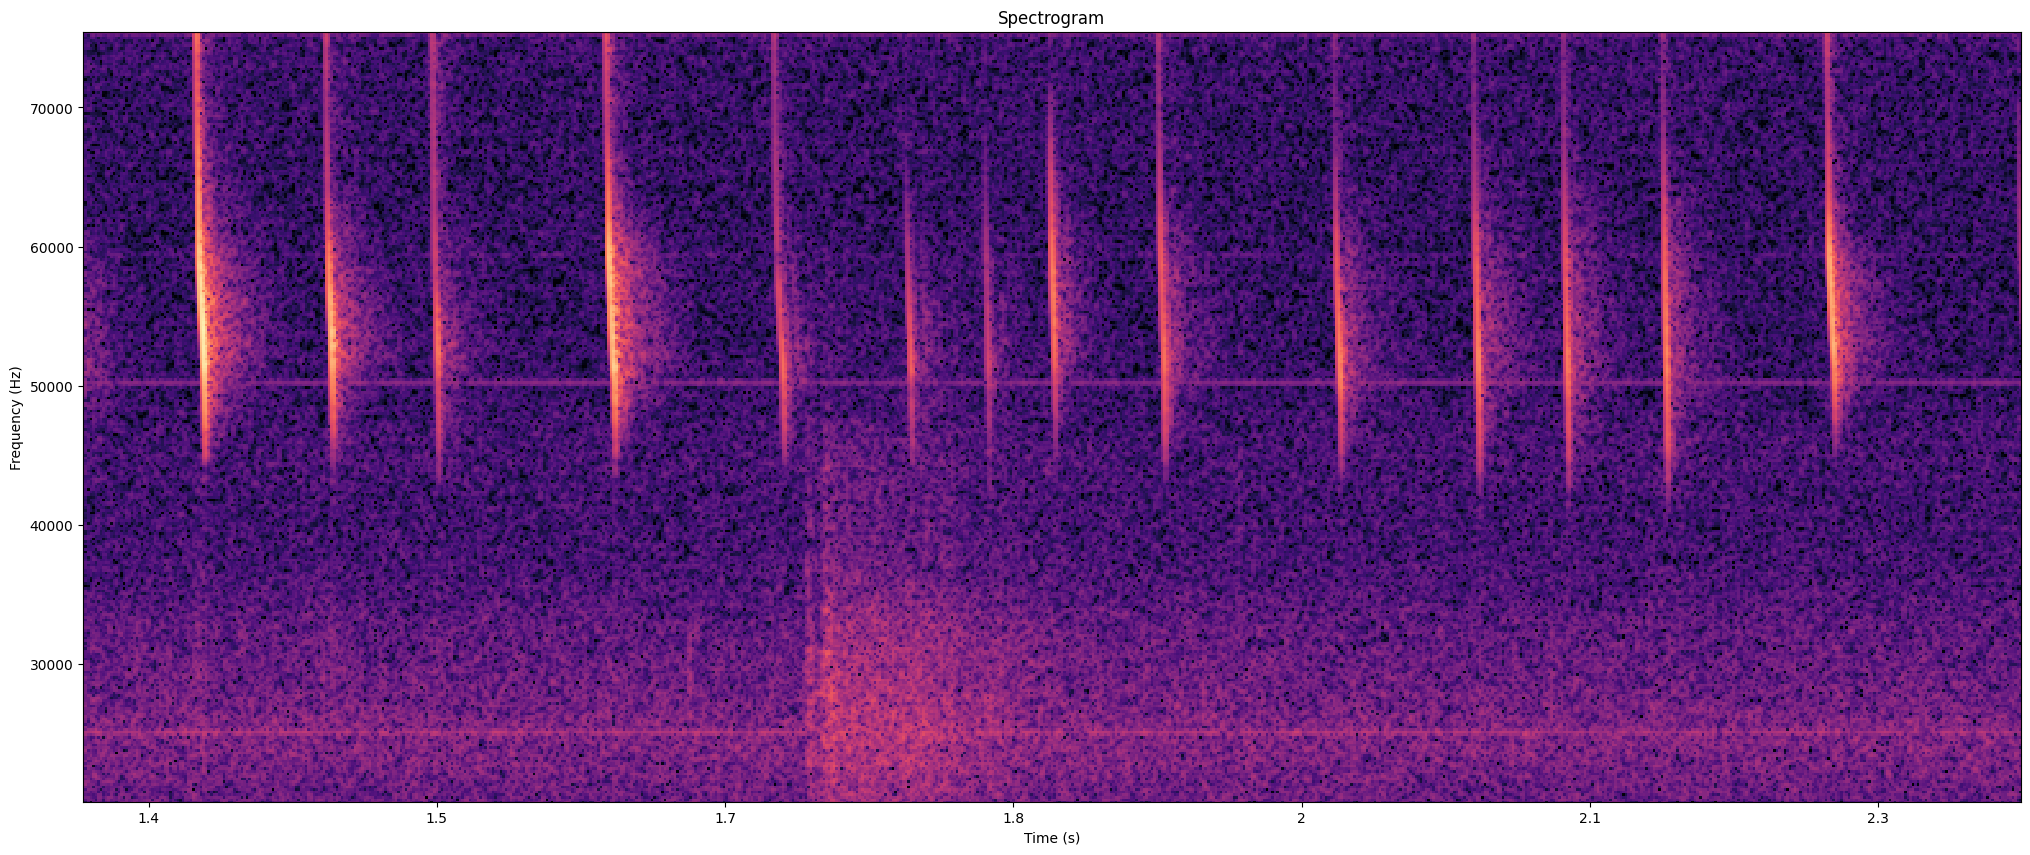

In [69]:
# Only the first call is an outlier in the slope, but it's pretty extreme, so lets check what's up here
unusual_call = 22
# Looking at call with unusual slope
plot_spectrogram_zoom(
    stft_bat_filtered_dB,
    sr,
    HOP_LENGTH_SPEC,
    "linear",
    df2.iloc[unusual_call]['min_freq'] - 5000,
    df2.iloc[unusual_call]['max_freq'] + 10000,
    df2.iloc[unusual_call]['start'] - 0.5,
    df2.iloc[unusual_call]['end'] + 0.5)

In [70]:
# This appears due to some blurry background noise, so lets clear out this outlier
df3.loc[22, 'max_energy_freq'] = np.nan

In [71]:
df3

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
1,0.060,0.066,6.0,20.0,25125.0,150750.0,56437.5,-20937.500000
2,0.092,0.098,6.0,20.0,22875.0,150750.0,57562.5,-21312.500000
3,0.118,0.144,26.0,30.0,24937.5,150750.0,57937.5,-4838.942308
5,0.530,0.592,62.0,40.0,20062.5,150750.0,NaN,-2107.862903
6,0.628,0.658,30.0,20.0,52875.0,77062.5,57937.5,-806.250000
7,0.678,0.692,14.0,50.0,53062.5,66187.5,56625.0,-937.500000
8,0.744,0.758,14.0,70.0,51187.5,66000.0,58875.0,-1058.035714
9,0.834,0.854,20.0,60.0,51187.5,77062.5,58125.0,-1293.750000
10,0.914,0.928,14.0,60.0,49500.0,66937.5,57937.5,-1245.535714
11,0.986,1.006,20.0,50.0,49500.0,75750.0,53062.5,-1312.500000


## Final statistics on the bat pass
Using the data frame, generate average call duration, average ICI, average min & max frequency, average frequency with most energy, and average call slope. Export data as an object.

In [72]:
# Generate key features from this bat pass and save in a dictionary
avg_duration_ms = df3['duration_ms'].mean()
avg_ici = df3['time_to_next_call_ms'].mean()
avg_min_freq = df3['min_freq'].mean()
avg_max_freq = df3['max_freq'].mean()
avg_freq_of_most_energy = df3['max_energy_freq'].mean()
avg_slope = df3['slope'].mean()

print('Bat pass features:')
print(f'Average call duration: {avg_duration_ms:.2f} ms')
print(f'Average ICI: {avg_ici:.2f} ms')
print(f'Average min frequency: {avg_min_freq / 1000:.2f} kHz')
print(f'Average max frequency: {avg_max_freq/1000:.2f} kHz')
print(f'Average frequency with most energy: {avg_freq_of_most_energy/1000:.2f} kHz')
print(f'Average call slope: {avg_slope:.2f} Hz/ms')

bat_pass_features = {
    'duration_ms': avg_duration_ms,
    'ici': avg_ici,
    'min_freq': avg_min_freq,
    'max_freq': avg_max_freq,
    'avg_freq_of_most_energy': avg_freq_of_most_energy,
    'avg_slope': avg_slope,
}
bat_pass_features

Bat pass features:
Average call duration: 14.26 ms
Average ICI: 54.05 ms
Average min frequency: 34.37 kHz
Average max frequency: 101.44 kHz
Average frequency with most energy: 53.92 kHz
Average call slope: -9523.21 Hz/ms


{'duration_ms': np.float64(14.263157894736842),
 'ici': np.float64(54.054054054054085),
 'min_freq': np.float64(34366.77631578947),
 'max_freq': np.float64(101442.43421052632),
 'avg_freq_of_most_energy': np.float64(53916.666666666664),
 'avg_slope': np.float64(-9523.205062083847)}

## Feeding buzz

In [73]:
# Looking at info on the feeding_buzz
feeding_buzz

start                       0.17400
end                         0.44200
duration_ms               268.00000
time_to_next_call_ms       90.00000
min_freq                20250.00000
max_freq                76500.00000
max_energy_freq         32812.50000
slope                    -209.88806
Name: 4, dtype: float64

(<Figure size 2500x1000 with 1 Axes>,
 <Axes: title={'center': 'Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

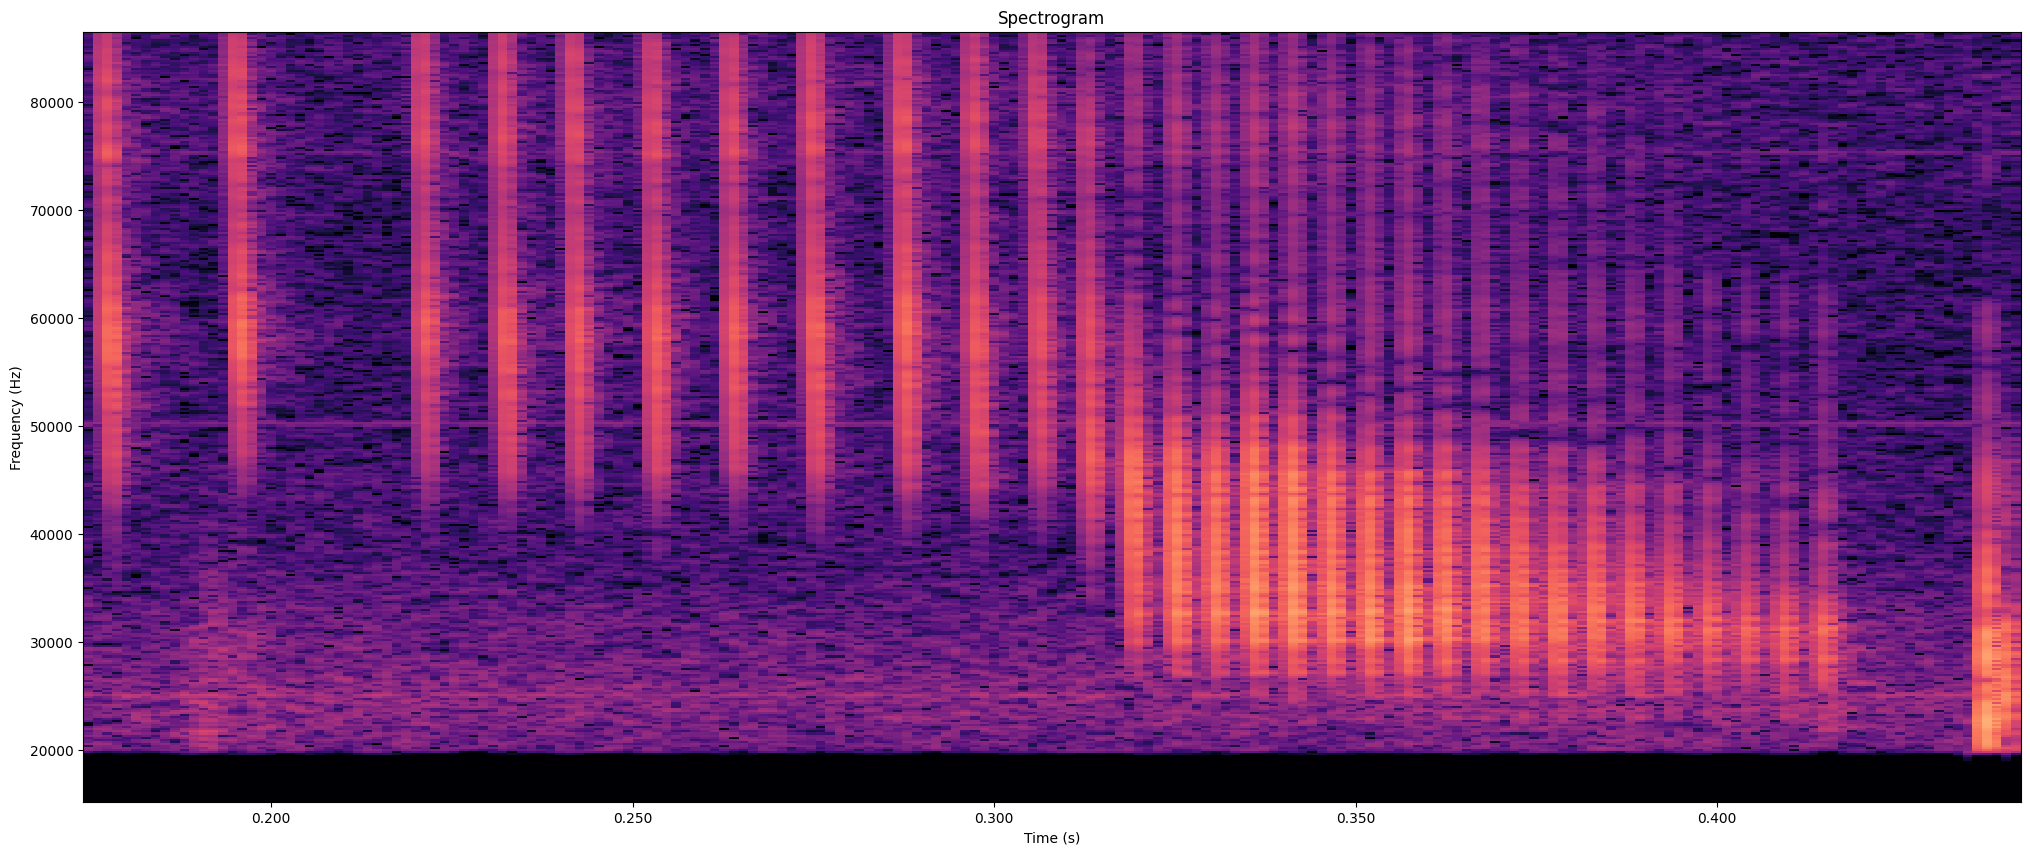

In [75]:
# Zoom in on that feeding buzz
# plot_spectrogram_zoom(stft_bat_dB, sr, HOP_LENGTH_SPEC, "linear", 22000, 50000, 0.25, 0.4)
# plot_spectrogram_zoom(stft_bat_dB, sr, HOP_LENGTH_SPEC, "linear", 22000, 50000, 0.25, 0.4)
plot_spectrogram_zoom(
    stft_bat_filtered_dB,
    sr,
    HOP_LENGTH_SPEC,
    "linear",
    feeding_buzz['min_freq'] - 5000,
    feeding_buzz['max_freq'] + 10000,
    feeding_buzz['start'],
    feeding_buzz['end'])

Look at that cool feeding buzz!